In [3]:
import torch

from src import get_model, HER2Dataset, get_dataloader, get_transforms, TRAIN_DIR

transform = get_transforms(is_train=False)
dataset = HER2Dataset(TRAIN_DIR, transform=transform)
loader = get_dataloader(dataset, batch_size=4, is_train=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(num_classes=4).to(device)
images, labels = next(iter(loader))

outputs = model(images.to(device))

print(f"Device: {device}")
print(f"Output shape: {outputs.shape}") 

Device: cpu
Output shape: torch.Size([4, 4])


In [5]:
import torch
from src.model import get_model

model = get_model(num_classes=4)

fake_image = torch.randn(1, 3, 224, 224)

with torch.no_grad():
    output = model(fake_image)

print(f"Output Tensor shape: {output.shape}")

Output Tensor shape: torch.Size([1, 4])


In [1]:
from src import save_checkpoint, MODELS_DIR
import torch

dummy_state = {
    'epoch': 1,
    'model_state_dict': {'layer.weight': torch.tensor([0.1, 0.2])},
    'optimizer_state_dict': {'lr': 0.001},
    'loss': 0.5
}

print("Attempting to save test checkpoint...")
save_checkpoint(dummy_state, filename="test_run.pth")

expected_file = MODELS_DIR / "test_run.pth"
if expected_file.exists():
    print(f"Test passed: File found at {expected_file}")
else:
    print("Test failed: File not found. Check your config.py paths.")

Attempting to save test checkpoint...
Checkpoint saved successfully at: D:\Github\Repositories\her2-classification\results\models\test_run.pth
Test passed: File found at D:\Github\Repositories\her2-classification\results\models\test_run.pth


In [ ]:
# Cell 4: Production-ready Training Loop
import torch
import torch.nn as nn
import torch.optim as optim
import os
import sys

# Ensure the right directory and paths are set
%cd /content/her2-classification
sys.path.append(os.getcwd())

from src import (
    TRAIN_DIR, TEST_DIR, 
    HER2Dataset, get_dataloader, get_transforms,
    get_model,
    train_one_epoch, validate,
    save_checkpoint, plot_history,
    config
)

# 1. Settings from config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Starting training session on device: {device}")

# 2. Prepare Data using dataset logic
train_tf = get_transforms(img_size=224, is_train=True)
val_tf = get_transforms(img_size=224, is_train=False)

train_ds = HER2Dataset(TRAIN_DIR, transform=train_tf)
val_ds = HER2Dataset(TEST_DIR, transform=val_tf)

train_loader = get_dataloader(train_ds, batch_size=config.BATCH_SIZE, is_train=True)
val_loader = get_dataloader(val_ds, batch_size=config.BATCH_SIZE, is_train=False)

# 3. Initialize Model, Loss, and Optimizer
model = get_model(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

# 4. Training Loop
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}
best_val_acc = 0.0

for epoch in range(config.EPOCHS):
    print(f"\nEpoch {epoch+1}/{config.EPOCHS}")
    

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Save History
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # Save Checkpoint using logic and MODELS_DIR from config
    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc
    
    checkpoint_data = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_acc': val_acc,
        'history': history
    }
    
    # Saving to Google Drive path
    save_checkpoint(checkpoint_data, is_best=is_best, checkpoint_dir=config.MODELS_DIR)

# 5. Finalize

print("\nTraining complete.")
plot_history(history, filename=os.path.join(config.PLOTS_DIR, "her2_training_results.png"))

Statistics for 30 epochs.
Environment: Local Machine. Saving results to: D:\Github\Repositories\her2-classification\results
✅ Wykres Seaborn zapisany w: ../results/plots/phase1_training_history.png


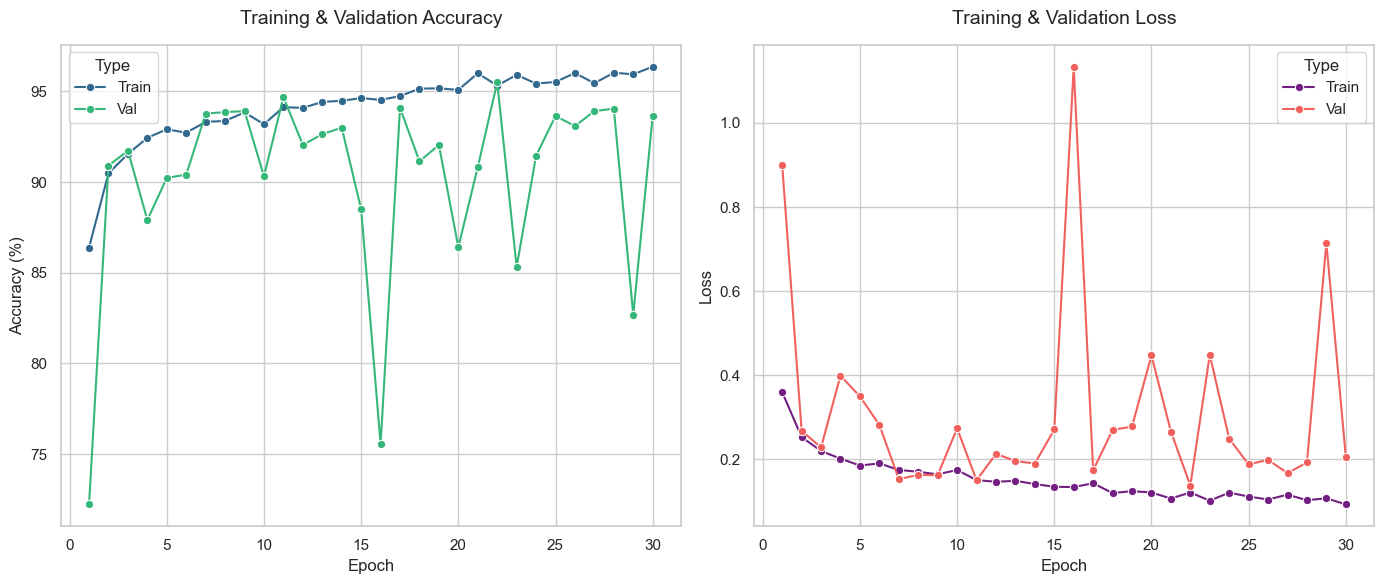

In [1]:
import re
import os

def load_history_from_logs(file_path):
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    if not os.path.exists(file_path):
        print(f"Error: File not found {file_path}")
        return None

    with open(file_path, 'r') as f:
        content = f.read()
        
        train_losses = re.findall(r"Train Loss: ([\d.]+)", content)
        train_accs = re.findall(r"Train Acc: ([\d.]+)%", content)
        val_losses = re.findall(r"Val Loss: ([\d.]+)", content)
        val_accs = re.findall(r"Val Acc: ([\d.]+)%", content)

        history['train_loss'] = [float(x) for x in train_losses]
        history['train_acc'] = [float(x) for x in train_accs]
        history['val_loss'] = [float(x) for x in val_losses]
        history['val_acc'] = [float(x) for x in val_accs]

    print(f"Statistics for {len(history['train_acc'])} epochs.")
    return history


log_path = "../results/logs/training_log_phase1.txt"
history_phase1 = load_history_from_logs(log_path)

if history_phase1:
    from src.utils import plot_history
    plot_history(history_phase1, save_path="../results/plots/phase1_training_history.png")